# Phase 1: Data Ingestion & Formatting

## Import Libraries

In [1]:
import numpy as np
import os, sys
import pandas as pd
import random
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix
import cv2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, UpSampling2D, Input
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import gc

I0000 00:00:1780204105.128437   16002 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1780204105.944503   16002 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1780204108.636026   16002 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


In [2]:
tf.test.gpu_device_name()
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)
os.environ['TF_DETERMINISTIC_OPS'] = '1'

I0000 00:00:1780204112.892231   16002 gpu_device.cc:2043] Created device /device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


In [3]:
tf.keras.backend.clear_session()
gc.collect()
print('Memory opimisation: ✅')

Memory opimisation: ✅


## Load the Dataset

In [4]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

/home/david_linux/my_tf_project/tf_env/lib/python3.12/site-packages/keras/src/datasets/cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


In [5]:
print(f"Raw - Max: {X_train.max()}")

Raw - Max: 255


## Normalization

In [6]:
X_train = X_train / 255.0
X_test  = X_test  / 255.0

In [7]:
X_train.shape

(50000, 32, 32, 3)

In [8]:
X_test.shape

(10000, 32, 32, 3)

In [9]:
print(f"Normalized - Max: {X_train.max()}")

Normalized - Max: 1.0


## One-Hot Encoding

In [ ]:
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# Mapped class Names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Phase 2: Data Augmentation

In [11]:
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

I0000 00:00:1780204129.989764   16002 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3536 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4050 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


# Phase 3: The CNN Architecture

In [12]:
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # 1. Augmentation Layer
    data_augmentation,

    # 2. Block One (32x32) : Looks for simple things like straight lines, edges, and basic colors
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)), # Result: 16x16

    # 3. Block Two (16x16) : Takes those lines and colors and starts seeing shapes—like a wheel, an eye, or a wing.
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'), # Increase Filters from 32 to 64 to capture more details.
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)), # Result: 8x8

    # 4. Dense Head
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5), # Imp for reducing Overfitting
    layers.Dense(10, activation='softmax')
])

> Why two blocks?

One layer isn't enough to understand a "car." We need the first block to see the edges and the second block to realize those edges form a door or a tire.

## Compilation & Summary

In [13]:
# 1. Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy', # Used because of One-Hot Encoding
    metrics=['accuracy']
)

# 2. Print the architecture summary
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 592,554 (2.26 MB)

 Trainable params: 591,914 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)


# Phase 4: Training & Protection

In [14]:
# Early Stoping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,               # How many epochs to wait before stopping
    restore_best_weights=True, # Automatically get back to the best epoch's weights
    verbose=1                   # It will print if the model stop at a certain epochs
)

# Saves the model at checkpoint
checkpoint = ModelCheckpoint(
    'best_customCNN_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)


# ReduceLROnPlateau : It will decrease the learning rate if the val loss is not improving.
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,   # Multiply the learning rate by 0.5
    patience=3,   # Wait 3 epochs before dropping it
    min_lr=1e-6,  # Don't let the learning rate go to absolute zero
    verbose=1
)

# Package them all into a list
callbacks_list = [early_stop, checkpoint, reduce_lr]

In [15]:
history = model.fit(
    X_train, y_train_cat,
    batch_size=128,
    epochs=50,
    validation_data=(X_test, y_test_cat),
    callbacks=callbacks_list
)


Epoch 1/50


E0000 00:00:1780200796.014841     977 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
I0000 00:00:1780200800.166529    1909 cuda_dnn.cc:461] Loaded cuDNN version 92101


391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.3676 - loss: 1.9585

E0000 00:00:1780200814.075620     977 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from None to 2.11796, saving model to best_customCNN_model.keras

Epoch 1: finished saving model to best_customCNN_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 19s 34ms/step - accuracy: 0.4354 - loss: 1.6597 - val_accuracy: 0.2998 - val_loss: 2.1180 - learning_rate: 0.0010
Epoch 2/50
389/391 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.5416 - loss: 1.2844
Epoch 2: val_loss improved from 2.11796 to 1.10811, saving model to best_customCNN_model.keras

Epoch 2: finished saving model to best_customCNN_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.5623 - loss: 1.2316 - val_accuracy: 0.6184 - val_loss: 1.1081 - learning_rate: 0.0010
Epoch 3/50
390/391 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6075 - loss: 1.1154
Epoch 3: val_loss improved from 1.10811 to 0.97892, saving model to best_customCNN_model.keras

Epoch 3: finished saving model to best_customCNN_model.keras
391/391 ━━━━━━━━━━━━━━━━━━━━ 12s 30ms/step - accuracy: 0.6190 - loss: 1

## Save Training History

In [17]:
import pickle

with open("customCNN_history.pkl", "wb") as f:
    pickle.dump(history.history, f)

print("Training history saved successfully!")

Training history saved successfully!


In [18]:
model = tf.keras.models.load_model('best_customCNN_model.keras') # Using the saved model so that I don't have to re-train the model everytime I open VS.
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       524,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,776,384 (6.78 MB)

 Trainable params: 591,914 (2.26 MB)

 Non-trainable params: 640 (2.50 KB)

 Optimizer params: 1,183,830 (4.52 MB)

## Evaluation

In [19]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc * 100:.2f}%")

E0000 00:00:1780201367.119168     977 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8183 - loss: 0.5484
Test Loss:     0.5484
Test Accuracy: 81.83%


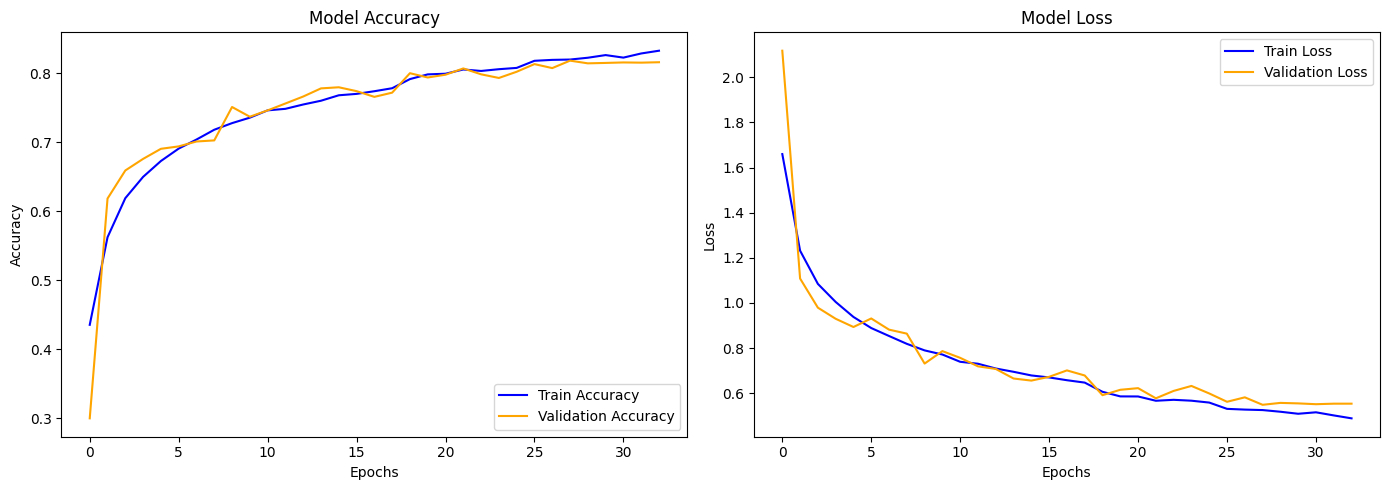

In [20]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import pickle

with open('customCNN_history.pkl', 'rb') as f:
     history_data = pickle.load(f)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_data['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_data['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_data['loss'], label='Train Loss', color='blue')
plt.plot(history_data['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()


## Confusion Matrix

  6/313 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step  

E0000 00:00:1780201375.941018     977 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step


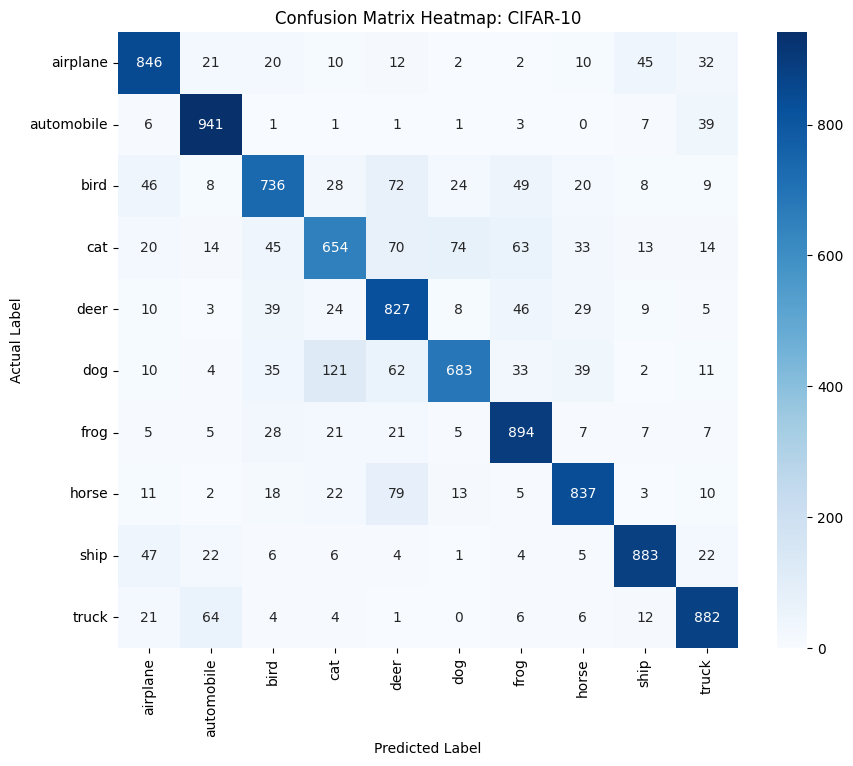

In [21]:
import seaborn as sns


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix Heatmap: CIFAR-10')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


### Brief of Heatmap Corelation


1.   Model is very confident for Automobile(947), Ship(879) and Frog(911).
2.   Model is not very confident for Cat, Dog and Bird.
3.   Model is struggling To differentiate between cat and dog because they have similar for texture And body parts.





| Actual → Predicted | Count | Why it makes sense |
|---|---|---|
| Dog → Cat | 113 | Similar body shape, fur texture |
| Airplane → Ship | 37 | Both on open backgrounds (sky/water) |
| Deer → Bird | 50 | Thin legs, outdoor scenes |
| Truck → Automobile | 73 | Both vehicles, similar features |

In [22]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.83      0.85      0.84      1000
  automobile       0.87      0.94      0.90      1000
        bird       0.79      0.74      0.76      1000
         cat       0.73      0.65      0.69      1000
        deer       0.72      0.83      0.77      1000
         dog       0.84      0.68      0.75      1000
        frog       0.81      0.89      0.85      1000
       horse       0.85      0.84      0.84      1000
        ship       0.89      0.88      0.89      1000
       truck       0.86      0.88      0.87      1000

    accuracy                           0.82     10000
   macro avg       0.82      0.82      0.82     10000
weighted avg       0.82      0.82      0.82     10000



1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


E0000 00:00:1780201594.594699     977 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


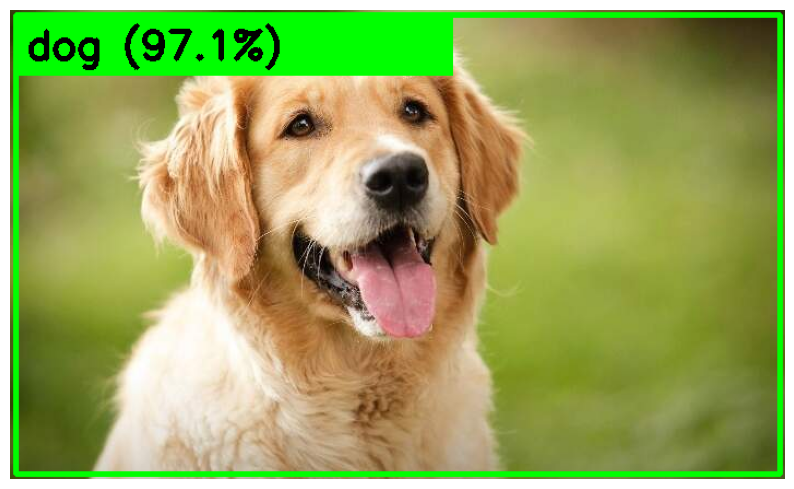

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


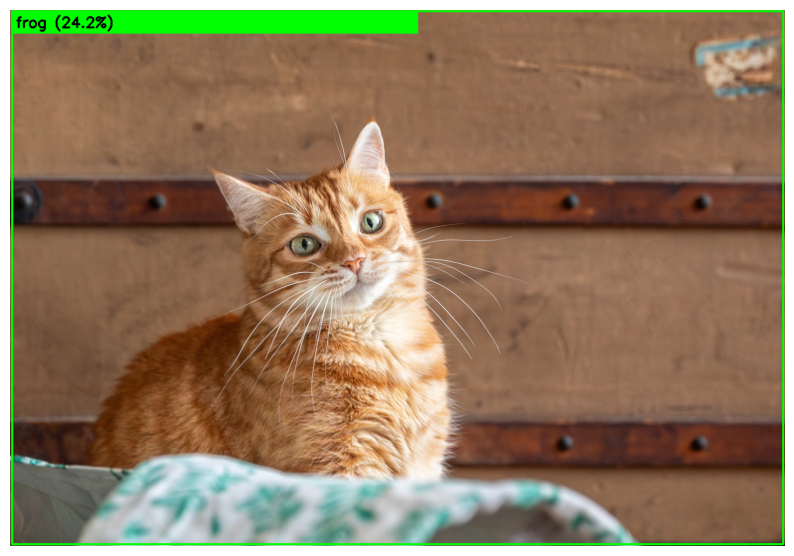

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


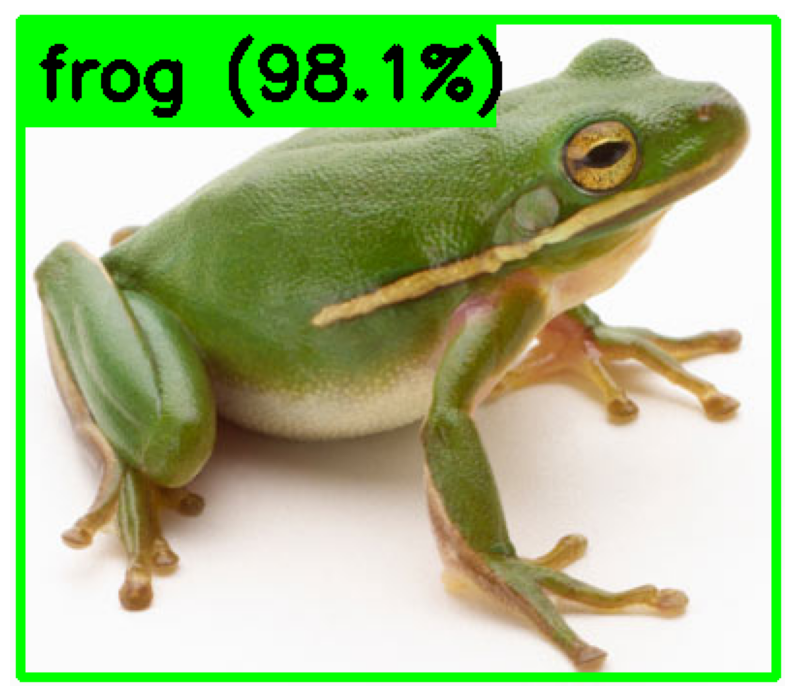

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


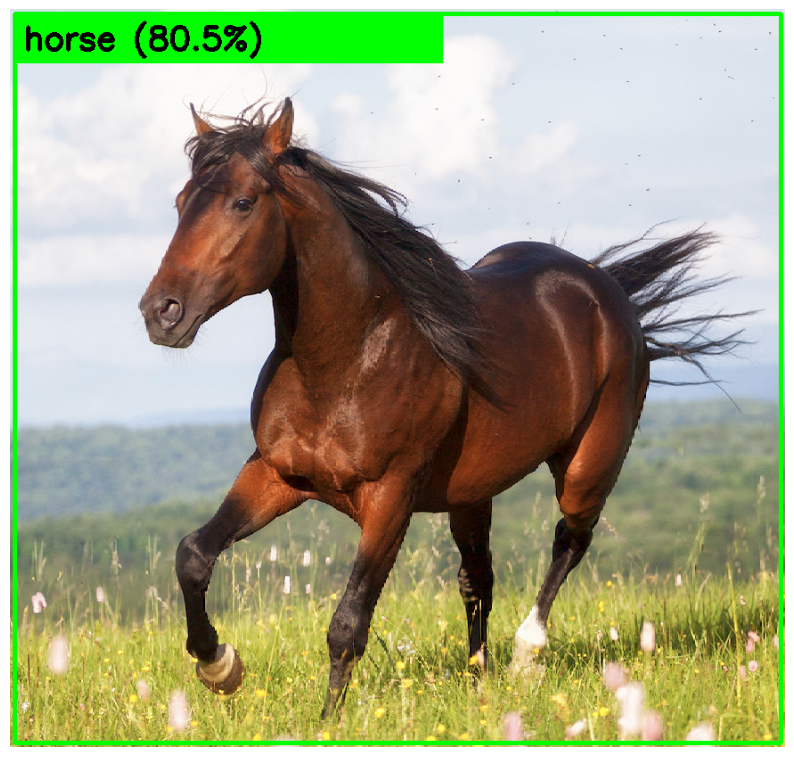

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


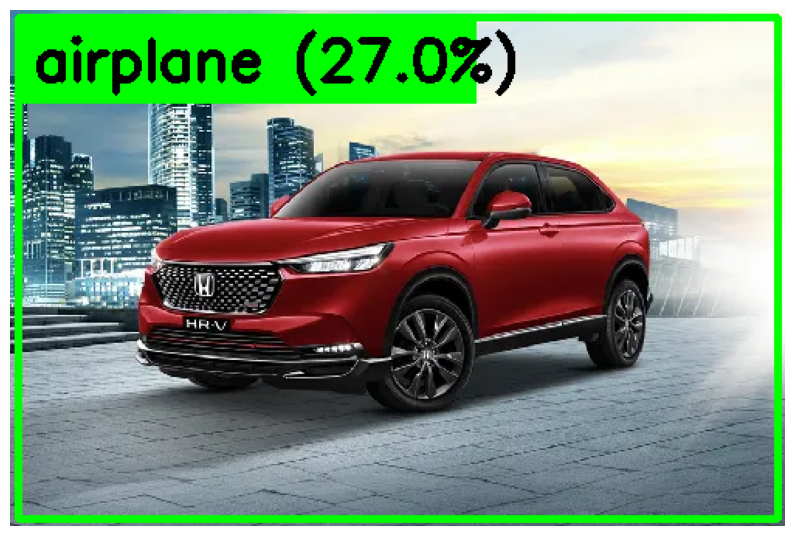

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step


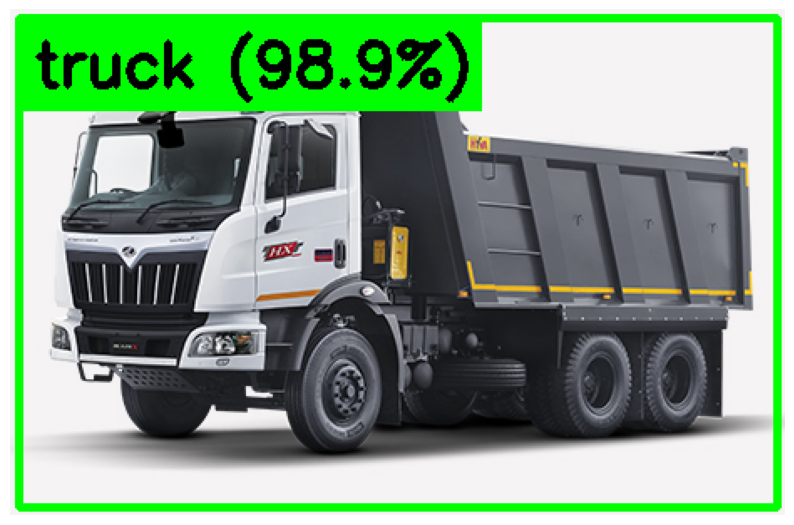

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


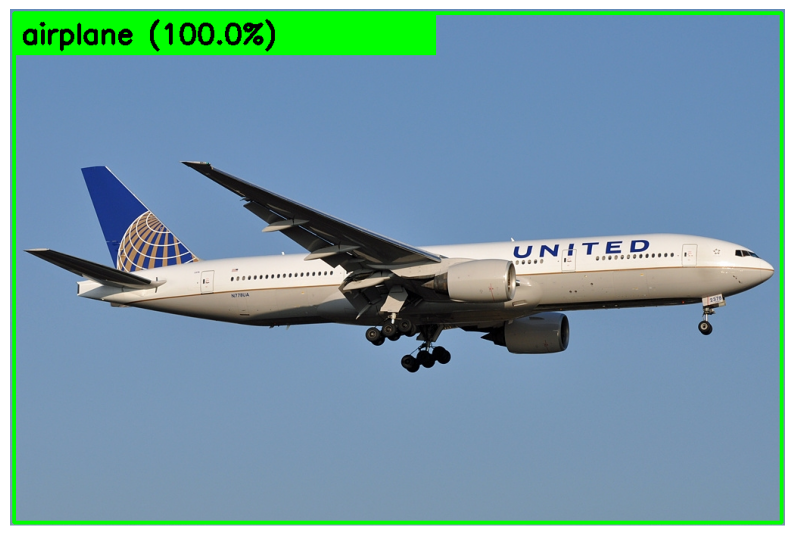

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


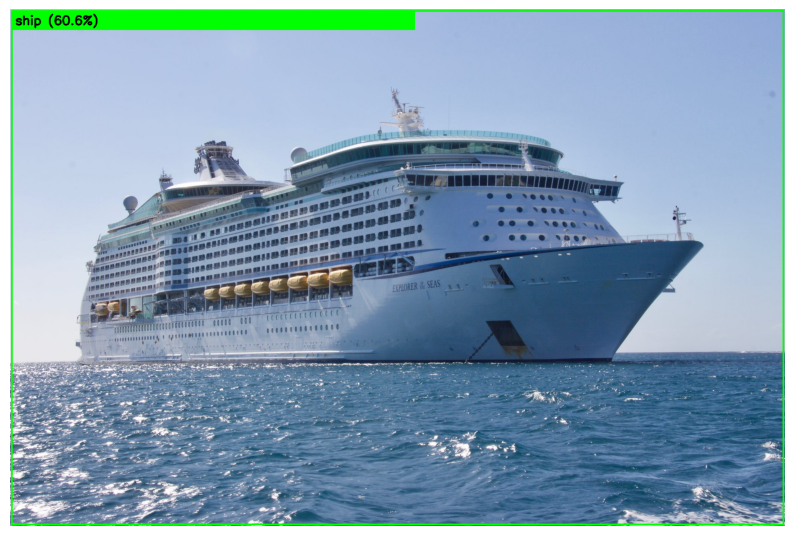

In [30]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def predict_local_image(image_path, model, class_names):
    # 1. Load the image from your computer
    img = cv2.imread(image_path)
    if img is None:
        print("Error: Could not find or open the image.")
        return

    # Create a copy for the display (keeps original resolution for viewing)
    display_img = img.copy()
    h, w, _ = display_img.shape

    # 2. Decompress/Resize to 32x32 for the model
    img_resized = cv2.resize(img, (32, 32))
    img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_BGR2RGB) # Convert BGR to RGB
    img_normalized = img_rgb.astype('float32') / 255.0
    img_batch = np.expand_dims(img_normalized, axis=0) # Add batch dimension

    # 3. Get Probability
    preds = model.predict(img_batch)[0]
    best_idx = np.argmax(preds)
    confidence = preds[best_idx] * 100
    result_text = f"{class_names[best_idx]} ({confidence:.1f}%)"

    # 4. Drawing the Overlay (Bounding box and Text)
    # Since CIFAR-10 classifies the WHOLE image, we draw the box around the borders
    cv2.rectangle(display_img, (5, 5), (w-5, h-5), (0, 255, 0), 3)

    # Draw a filled background for the text
    cv2.rectangle(display_img, (5, 5), (w//2 + 50, 60), (0, 255, 0), -1)
    cv2.putText(display_img, result_text, (15, 45),
                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 0, 0), 3)

    # 5. Show the Result
    plt.figure(figsize=(10, 10))
    plt.imshow(cv2.cvtColor(display_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()

# How to use it:
predict_local_image('Test Images/golden-retriever-tongue-out.jpg', model, class_names)
predict_local_image('Test Images/cat.jpg', model, class_names)
predict_local_image('Test Images/frog.jpg', model, class_names)
predict_local_image('Test Images/horse.png', model, class_names)
predict_local_image('Test Images/car.webp', model, class_names)
predict_local_image('Test Images/truck.jpg', model, class_names)
predict_local_image('Test Images/plane.jpg', model, class_names)
predict_local_image('Test Images/ship.jpeg', model, class_names)

## Creating the GRADCam Model

In [31]:
for layer in model.layers:
    print(layer.name, layer.output.shape)

sequential (None, 32, 32, 3)
conv2d (None, 32, 32, 32)
batch_normalization (None, 32, 32, 32)
conv2d_1 (None, 32, 32, 32)
batch_normalization_1 (None, 32, 32, 32)
max_pooling2d (None, 16, 16, 32)
conv2d_2 (None, 16, 16, 64)
batch_normalization_2 (None, 16, 16, 64)
conv2d_3 (None, 16, 16, 64)
batch_normalization_3 (None, 16, 16, 64)
max_pooling2d_1 (None, 8, 8, 64)
flatten (None, 4096)
dense (None, 128)
batch_normalization_4 (None, 128)
dropout (None, 128)
dense_1 (None, 10)


## GradCAM Explainability

In [32]:
def get_gradcam_heatmap(img_array, model, last_conv_layer_name): # 3 Inputs

    with tf.GradientTape() as tape:  # tensorflow records operations for automatic differentiation

        """ 
        Manually run forward pass layer by layer
        This replaces grad_model because .output breaks with nested Sequential
        """
        x = tf.cast(img_array, tf.float32)  #   Converting the Numpy array into the tensor flow Compatible float format.
        conv_outputs = None # will be filled when it hits the target conv layer during Fwd pass.

        for layer in model.layers: # will work through every single layer one by one
            x = layer(x, training=False) # Disabling the trainings so that it won't learn

            # Capture output right after the target conv layer
            if layer.name == last_conv_layer_name: # Image reaches to the canv layer before flattening.
                conv_outputs = x 
                tape.watch(conv_outputs)  # Tell tape to track this conv_output

        predictions = x  # Final output after all layers

        class_channel = predictions[:, np.argmax(predictions[0])] # Finds the class with highest score & isolates just the class score

    grads = tape.gradient(class_channel, conv_outputs) # Finds how much did that specific  conv layer influence the final single class score

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2)) # Calculate the average importance of each filter

    conv_outputs = conv_outputs[0] # Removes the batch dimension

    # multiplication each feature map with its imporance weight and then summing up
    # weighted sum of feature maps
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis] 

    # remove any extra dimensions
    heatmap = tf.squeeze(heatmap)

    # remove any negative values and normalize the values between 0 and 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step


E0000 00:00:1780201666.373108     977 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


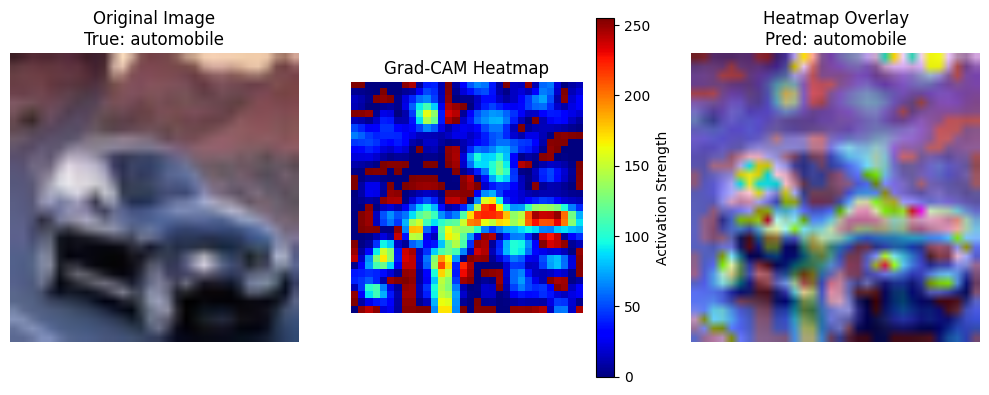

In [34]:
last_conv_layer = "conv2d_3" # Defined the last conv layer


idx = 390  # from index 0–9999, fetching images from X_test

# X_test is already normalized [0,1]
# We need raw 0-255 version for display and overlay
img_array = X_test[idx] * 255.0       # De-normalizing by *255.0                

# Prepare input for model (already normalized, just add batch dim, axis=0), basically adding the batch dimn
input_array = np.expand_dims(X_test[idx], axis=0)     # (1, 32, 32, 3)

# here we are calling the function
heatmap = get_gradcam_heatmap(input_array, model, last_conv_layer)

# Resize heatmap to match CIFAR image size (32x32)
heatmap = cv2.resize(heatmap, (32, 32), interpolation=cv2.INTER_CUBIC)

# Normalize heatmap from [0,1]--->[0, 255]
heatmap = np.uint8(255 * heatmap)

# Apply color map
heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Overlay heatmap on original image
superimposed_img = heatmap_color * 0.4 + img_array

# Plot results
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_array.astype("uint8"), interpolation='bilinear')
plt.title(f"Original Image\nTrue: {class_names[y_test[idx][0]]}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap, cmap='jet')
plt.title("Grad-CAM Heatmap")
plt.colorbar(label="Activation Strength")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img.astype("uint8"), interpolation='bilinear')
plt.title(f"Heatmap Overlay\nPred: {class_names[np.argmax(model.predict(input_array))]}")
plt.axis("off")

plt.tight_layout()
plt.show()

## Implementing DenseNet121 Transfer Learning on CIFAR-10

In [ ]:
"""from tensorflow.keras.applications.densenet import DenseNet121, preprocess_input
from tensorflow.keras.layers import Dense, UpSampling2D, Dropout
from tensorflow.keras.models import Sequential

# 1. Define the base model with the UPSAMPLED shape (96x96)
base_model = DenseNet121(input_shape=(96, 96, 3), include_top=False, weights='imagenet', pooling='avg')

# 2. Build the sequential model
model = Sequential()

# Add your data_augmentation layer (already defined in your earlier steps)
model.add(data_augmentation) 

# Resize images from 32x32 to 96x96
model.add(UpSampling2D(size=(3,3), input_shape=(32, 32, 3)))

# Add the DenseNet feature extractor
model.add(base_model)

# 3. Regularization to close that 10% accuracy gap
model.add(Dropout(0.5)) 

# 4. Final output layer for 10 classes
model.add(Dense(10, activation='softmax'))

# 5. Compile
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# 6. Fit (Use the generator to keep the data augmentation running)
r = model.fit(
    X_train, 
    y_train_cat, 
    epochs=100, 
    batch_size=64,             # Standard batch size for CIFAR-10
    validation_data=(X_test, y_test_cat),
    callbacks=callbacks_list,
    shuffle=True               # Highly recommended to shuffle your training data
)
"""

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 312ms/step - accuracy: 0.5701 - loss: 1.3733
Epoch 1: val_loss did not improve from 0.75654
782/782 ━━━━━━━━━━━━━━━━━━━━ 295s 326ms/step - accuracy: 0.6821 - loss: 0.9756 - val_accuracy: 0.7345 - val_loss: 0.8431 - learning_rate: 0.0010
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 323ms/step - accuracy: 0.7705 - loss: 0.6965
Epoch 2: val_loss improved from 0.75654 to 0.48113, saving model to best_cifar10_model.keras

Epoch 2: finished saving model to best_cifar10_model.keras
782/782 ━━━━━━━━━━━━━━━━━━━━ 263s 336ms/step - accuracy: 0.7909 - loss: 0.6288 - val_accuracy: 0.8359 - val_loss: 0.4811 - learning_rate: 0.0010
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step - accuracy: 0.8301 - loss: 0.5103
Epoch 3: val_loss did not improve from 0.48113
782/782 ━━━━━━━━━━━━━━━━━━━━ 250s 320ms/step - accuracy: 0.8337 - loss: 0.4947 - val_accuracy: 0.8112 - val_loss: 0.5569 - learning_rate: 0.0010
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 308ms/s

# CIFAR-10 Training Summary

## Final Results

| Metric | Value |
|---|---|
| Best Accuracy | 94.47% |
| Best Val Loss | 0.2089 |
| Best Epoch | 17 |
| Training Stopped | Epoch 22 |

---

## Training Progress

| Epoch | Accuracy | Val Accuracy | Val Loss | Notes |
|---|---|---|---|---|
| 1 | 68.2% | 73.4% | 0.8431 | Initial training |
| 2 | 79.0% | 83.5% | 0.4811 | Model saved |
| 6 | 90.4% | 90.3% | 0.2868 | Major improvement |
| 11 | 95.2% | 92.4% | 0.2423 | LR reduced |
| 17 | 97.9% | **94.4%** | **0.2089** | Best model |
| 22 | 99.0% | 94.2% | 0.2468 | Early stopping |

---

## Notes

- Learning rate reduced multiple times for stability.
- Best performance achieved at Epoch 17.
- Slight overfitting observed after Epoch 17.
- Early stopping restored best weights automatically.

### Model Training Time (DenseNet): 95m

## Save the History & Evaluation Data

In [ ]:
import pickle

# 1. Save the history object to a file
with open('densenet_history.pkl', 'wb') as f:
    pickle.dump(r.history, f)

print("Training history has been saved as 'densenet_history.pkl'")


NameError: name 'r' is not defined

In [ ]:
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
import pickle

# 1. Load the 'Golden Model'
best_model = load_model('best_densenet121_model.keras')

# 2. Final Evaluation
print("Evaluating the Best Model...")
evaluation = best_model.evaluate(X_test, y_test_cat)
print(f"Final Test Loss: {evaluation[0]:.4f}")
print(f"Final Test Accuracy: {evaluation[1]*100:.2f}%")

# 3. Load the history (if you are running this in a new session)
with open('densenet_history.pkl', 'rb') as f:
     history_data = pickle.load(f)
# If you are still in the same session, we can just use 'r.history'
# history_data = r.history 

# 4. Plotting (Using your preferred style)
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_data['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history_data['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.axvline(x=16, color='red', linestyle='--', label='Best Model (Epoch 17)') # Mark where it saved
plt.title('Model Accuracy (DenseNet121)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_data['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history_data['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.axvline(x=16, color='red', linestyle='--', label='Best Model (Epoch 17)')
plt.title('Model Loss (DenseNet121)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Evaluating the Best Model...


E0000 00:00:1778754152.622260    1017 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.9446 - loss: 0.2089
Final Test Loss: 0.2089
Final Test Accuracy: 94.46%


EOFError: Ran out of input

## Confusion Matrix

E0000 00:00:1778754168.216843    1017 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 32ms/step


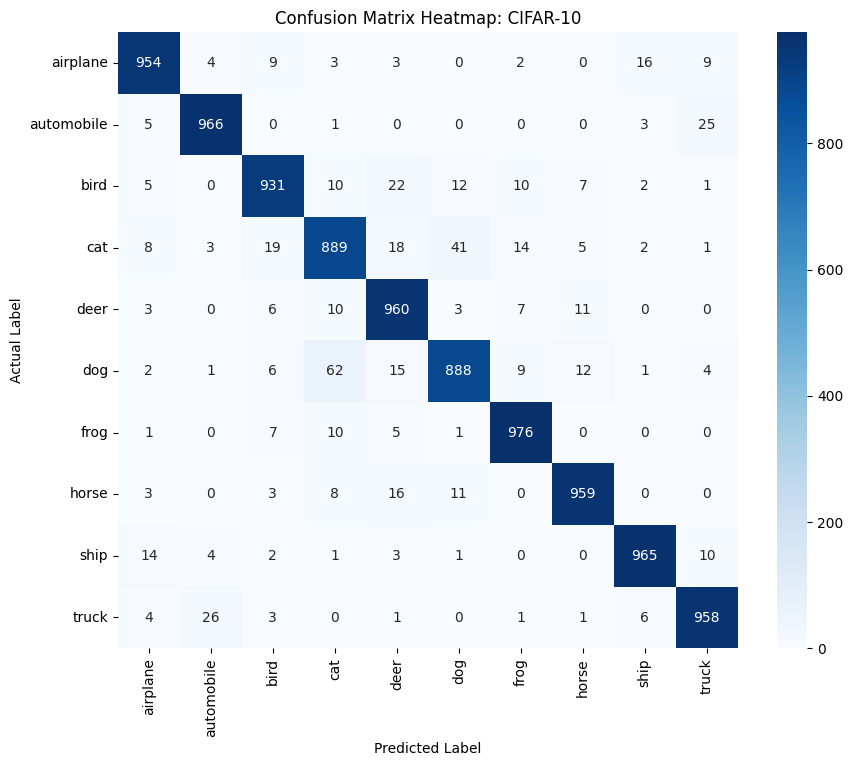

In [ ]:
import seaborn as sns


y_pred = best_model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix Heatmap: CIFAR-10')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


 Confusion Matrix Observations (CIFAR-10)

## Overall Performance
- The model demonstrates strong classification performance across most CIFAR-10 classes.
- Most predictions are concentrated along the diagonal of the confusion matrix, indicating high accuracy.
- Several classes achieved prediction accuracy above **95%**, showing that the DenseNet121 model learned meaningful visual features effectively.

---

# Class-wise Observations

| Class | Correct Predictions | Observation |
|---|---|---|
| Airplane | 954 | Strong performance with slight confusion toward ship and truck. |
| Automobile | 966 | Very high accuracy with minor confusion with truck. |
| Bird | 931 | Moderate confusion with deer, dog, and cat. |
| Cat | 889 | One of the weakest-performing classes; heavily confused with dog. |
| Deer | 960 | Strong classification with small confusion toward horse and cat. |
| Dog | 888 | Lowest-performing class; frequently confused with cat. |
| Frog | 976 | Best-performing class with highly distinct features. |
| Horse | 959 | High accuracy with minor confusion toward deer. |
| Ship | 965 | Strong performance with slight confusion toward airplane. |
| Truck | 958 | Excellent accuracy with small confusion toward automobile. |

---


## Classifiaction Report

In [ ]:
print(classification_report(y_true, y_pred_classes, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.95      0.95      0.95      1000
  automobile       0.96      0.97      0.96      1000
        bird       0.94      0.93      0.94      1000
         cat       0.89      0.89      0.89      1000
        deer       0.92      0.96      0.94      1000
         dog       0.93      0.89      0.91      1000
        frog       0.96      0.98      0.97      1000
       horse       0.96      0.96      0.96      1000
        ship       0.97      0.96      0.97      1000
       truck       0.95      0.96      0.95      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



## Finding Last layer of DenseNet121

In [ ]:
densenet_base = best_model.get_layer('densenet121')

# Print last 15 layers of DenseNet to find the target layer
for layer in densenet_base.layers[-15:]:
    print(layer.name, '→', layer.output.shape)

conv5_block15_1_conv → (None, 3, 3, 128)
conv5_block15_1_bn → (None, 3, 3, 128)
conv5_block15_1_relu → (None, 3, 3, 128)
conv5_block15_2_conv → (None, 3, 3, 32)
conv5_block15_concat → (None, 3, 3, 992)
conv5_block16_0_bn → (None, 3, 3, 992)
conv5_block16_0_relu → (None, 3, 3, 992)
conv5_block16_1_conv → (None, 3, 3, 128)
conv5_block16_1_bn → (None, 3, 3, 128)
conv5_block16_1_relu → (None, 3, 3, 128)
conv5_block16_2_conv → (None, 3, 3, 32)
conv5_block16_concat → (None, 3, 3, 1024)
bn → (None, 3, 3, 1024)
relu → (None, 3, 3, 1024)
avg_pool → (None, 1024)


In [ ]:
def get_densenet_gradcam_heatmap(img_array, model, last_conv_layer_name):

    # ── Step 1: Get the DenseNet sub-model ──
    # DenseNet121 is Functional API internally — we can use .get_layer() inside it
    densenet_base = model.get_layer('densenet121')

    # Build a mini model that outputs BOTH the target conv AND the DenseNet output
    # This works because DenseNet is Functional API — .output is accessible here
    densenet_grad_model = tf.keras.Model(
        inputs  = densenet_base.input,
        outputs = [
            densenet_base.get_layer(last_conv_layer_name).output,  # conv output we want
            densenet_base.output                                    # DenseNet final output
        ]
    )

    with tf.GradientTape() as tape:

        # ── Step 2: Manually run the OUTER Sequential layer by layer ──
        # Same reason as Custom CNN — outer Sequential breaks .output
        x = tf.cast(img_array, tf.float32)
        conv_outputs = None

        for layer in model.layers:

            if layer.name == 'densenet121':
                # ── Step 3: When we hit DenseNet, run the grad model ──
                # We get BOTH the conv output AND DenseNet's final output in one call
                conv_outputs, x = densenet_grad_model(x, training=False)
                tape.watch(conv_outputs)  # Tell tape to track this

            else:
                # All other layers (UpSampling, Dropout, Dense) run normally
                x = layer(x, training=False)

        predictions = x  # Final softmax output

        class_channel = predictions[:, np.argmax(predictions[0])]

    # ── Step 4: Everything below is identical to before ──
    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)

    return heatmap.numpy()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


E0000 00:00:1778754202.302545    1017 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


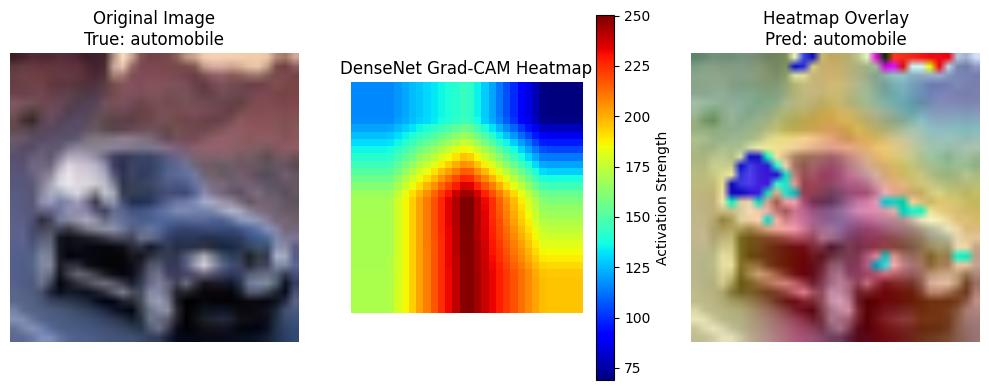

In [ ]:
from tensorflow.keras.applications.densenet import preprocess_input

# Target layer — the last concatenation in DenseNet's final dense block
# Contains ALL accumulated feature maps — richest representation in the network
last_densenet_conv = 'conv5_block16_concat'  # ← update if your print shows different name

idx = 390  # any test image 0-9999

# Display version (de-normalized)
img_display = X_test[idx] * 255.0

# DenseNet needs its own preprocessing (same concept as ResNet — mean subtraction)
img_preprocessed = preprocess_input(img_display.copy())
input_array = np.expand_dims(img_preprocessed, axis=0)  # (1, 32, 32, 3)

# Generate heatmap
heatmap = get_densenet_gradcam_heatmap(input_array, best_model, last_densenet_conv)

# Heatmap will be small (based on DenseNet's output spatial size)
# Resize back to 32x32 to overlay on original image
heatmap_resized = cv2.resize(heatmap, (32, 32))
heatmap_uint8   = np.uint8(255 * heatmap_resized)

# Colormap + BGR fix
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# Blend
superimposed_img = heatmap_color * 0.4 + img_display

# Prediction
pred_class = class_names[np.argmax(model.predict(input_array))]
true_class  = class_names[y_test[idx][0]]

# Plot
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_display.astype("uint8"), interpolation='bilinear')
plt.title(f"Original Image\nTrue: {true_class}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_uint8, cmap='jet')
plt.title("DenseNet Grad-CAM Heatmap")
plt.colorbar(label="Activation Strength")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img.astype("uint8"), interpolation='bilinear')
plt.title(f"Heatmap Overlay\nPred: {pred_class}")
plt.axis("off")

plt.tight_layout()
plt.show()

## Transfer Learning: EfficientNetV2-Medium

In [16]:
from tensorflow.keras.applications import EfficientNetV2M
from tensorflow.keras import layers, models

# Build with Functional API (cleaner, avoids nested Sequential issues)
inputs = layers.Input(shape=(32, 32, 3))

x = layers.Rescaling(scale=255.0)(inputs)


# Preprocessing inline — no nested Sequential
x = layers.Resizing(224, 224, interpolation='bilinear')(x)
x = layers.RandomFlip("horizontal")(x)
x = layers.RandomRotation(0.1)(x)
x = layers.RandomZoom(0.1)(x)

# EfficientNetV2M handles normalization internally
base_model = EfficientNetV2M(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

x = base_model(x, training=False)  # training=False keeps BN frozen

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='swish')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs, name='EfficientNetV2M_CIFAR10')

In [17]:
model.compile(
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1), 
    optimizer=Adam(learning_rate=0.001), # Explicitly set to 0.001 for head training
    metrics=['accuracy']
)

model.summary()

Model: "EfficientNetV2M_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 7, 7, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,481,918 (204.02 MB)

 Trainable params: 331,018 (1.26 MB)

 Non-trainable params: 53,150,900 (202.75 MB)

In [18]:
EffNetV2_phase1 = model.fit(
    X_train, y_train_cat, 
    
    epochs=10,             
    batch_size=32, 
    validation_data=(X_test, y_test_cat),
    verbose=1
)

Epoch 1/10


E0000 00:00:1780204545.422016   16002 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - accuracy: 0.7465 - loss: 1.2709

E0000 00:00:1780204905.194479   16002 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 426s 260ms/step - accuracy: 0.7911 - loss: 1.0831 - val_accuracy: 0.9182 - val_loss: 0.7393
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 395s 253ms/step - accuracy: 0.8298 - loss: 0.9418 - val_accuracy: 0.9185 - val_loss: 0.7261
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 395s 253ms/step - accuracy: 0.8361 - loss: 0.9215 - val_accuracy: 0.9245 - val_loss: 0.7164
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 403s 258ms/step - accuracy: 0.8395 - loss: 0.9126 - val_accuracy: 0.9249 - val_loss: 0.7092
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 397s 254ms/step - accuracy: 0.8470 - loss: 0.9023 - val_accuracy: 0.9266 - val_loss: 0.7033
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 396s 254ms/step - accuracy: 0.8470 - loss: 0.8979 - val_accuracy: 0.9287 - val_loss: 0.7006
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 394s 252ms/step - accuracy: 0.8527 - loss: 0.8839 - val_accuracy: 0.9284 - val_loss: 0.6975
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 453s 259ms/step - accuracy: 0.8

In [19]:
UNFREEZE_FROM = -30   # Tune this number — more negative = more layers open

base_model.trainable = True

unfrozen_count = 0
frozen_count   = 0
bn_count       = 0

for layer in base_model.layers[:UNFREEZE_FROM]:
    # Everything before the cutoff stays frozen
    layer.trainable = False
    frozen_count += 1

for layer in base_model.layers[UNFREEZE_FROM:]:
    if isinstance(layer, layers.BatchNormalization):
        # BN layers stay frozen regardless — protects activation distributions
        layer.trainable = False
        bn_count += 1
    else:
        layer.trainable = True
        unfrozen_count += 1

print(f"Unfrozen conv layers : {unfrozen_count}")
print(f"Frozen base layers   : {frozen_count}")
print(f"Frozen BN layers     : {bn_count}")


EPOCHS_PHASE2 = 20
BATCH_SIZE    = 32
STEPS_PER_EPOCH = len(X_train) // BATCH_SIZE

lr_schedule = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate = 1e-5,
    decay_steps           = EPOCHS_PHASE2 * STEPS_PER_EPOCH,
    alpha                 = 0.01   # Floor: LR won't drop below 1e-5 * 0.01 = 1e-7
)


# Callbacks
early_stop = EarlyStopping(
    monitor             = 'val_loss',
    patience            = 3,                # Tighter than Phase 1 — only 10 epochs total
    restore_best_weights= True,
    verbose             = 1
)

checkpoint = ModelCheckpoint(
    'best_EfficientNetV2M_model.keras',
    monitor      = 'val_loss',
    save_best_only = True,
    verbose      = 1
)

callbacks_phase2 = [early_stop, checkpoint]


# Compile

model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate=lr_schedule),
    loss      = tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics   = ['accuracy']
)

Unfrozen conv layers : 24
Frozen base layers   : 710
Frozen BN layers     : 6


In [20]:
model.summary()

Model: "EfficientNetV2M_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 7, 7, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 53,481,918 (204.02 MB)

 Trainable params: 7,339,530 (28.00 MB)

 Non-trainable params: 46,142,388 (176.02 MB)

In [21]:
print("\n── Phase 2: Selective Fine-Tuning ──")
effnet_history_p2 = model.fit(
    X_train, y_train_cat,
    validation_data = (X_test, y_test_cat),
    epochs          = EPOCHS_PHASE2,
    batch_size      = BATCH_SIZE,
    callbacks       = callbacks_phase2,
    verbose         = 1
)


── Phase 2: Selective Fine-Tuning ──
Epoch 1/20


E0000 00:00:1780208677.112581   16002 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}
E0000 00:00:1780208695.228600   16002 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetV2M_CIFAR10_1/efficientnetv2-m_1/block1b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - accuracy: 0.8696 - loss: 0.8458

E0000 00:00:1780209075.965748   16002 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}



Epoch 1: val_loss improved from None to 0.66996, saving model to best_EfficientNetV2M_model.keras

Epoch 1: finished saving model to best_EfficientNetV2M_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 466s 285ms/step - accuracy: 0.8742 - loss: 0.8347 - val_accuracy: 0.9393 - val_loss: 0.6700
Epoch 2/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 238ms/step - accuracy: 0.8774 - loss: 0.8254
Epoch 2: val_loss improved from 0.66996 to 0.66125, saving model to best_EfficientNetV2M_model.keras

Epoch 2: finished saving model to best_EfficientNetV2M_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 438s 280ms/step - accuracy: 0.8806 - loss: 0.8183 - val_accuracy: 0.9439 - val_loss: 0.6612
Epoch 3/20
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - accuracy: 0.8860 - loss: 0.8070
Epoch 3: val_loss improved from 0.66125 to 0.65598, saving model to best_EfficientNetV2M_model.keras

Epoch 3: finished saving model to best_EfficientNetV2M_model.keras
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 451s 288ms/step - accuracy: 0.8897 - l

# Saving Training History

In [23]:
import pickle

with open("EfficientNetV2_history.pkl", "wb") as f:
    pickle.dump(effnet_history_p2.history, f)

print("Training history saved successfully!")

Training history saved successfully!


# Training History Plot

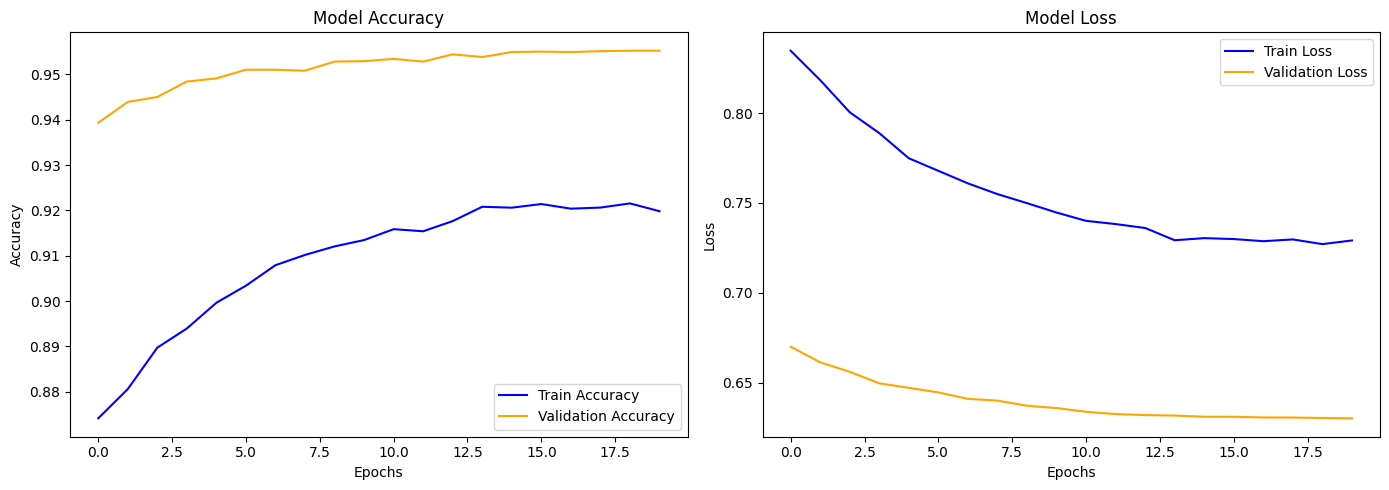

In [24]:
with open('EfficientNetV2_history.pkl', 'rb') as f:
     history_data = pickle.load(f)

plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_data['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history_data['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_data['loss'], label='Train Loss', color='blue')
plt.plot(history_data['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')

plt.tight_layout()
plt.show()

# Load Saved EfficientNet-V2 Model

In [25]:
model = tf.keras.models.load_model('best_EfficientNetV2M_model.keras') # Using the saved model so that I don't have to re-train the model everytime I open VS.
model.summary()

Model: "EfficientNetV2M_CIFAR10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_4 (Rescaling)         │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resizing_2 (Resizing)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_3 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_3               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_3 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-m (Functional)   │ (None, 7, 7, 1280)     │    53,150,388 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 68,160,979 (260.01 MB)

 Trainable params: 7,339,530 (28.00 MB)

 Non-trainable params: 46,142,388 (176.02 MB)

 Optimizer params: 14,679,061 (56.00 MB)

# EfficientNet-V2 Evaluation

In [26]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat, verbose=1)
print(f"EfficientNet Test Loss:     {test_loss:.4f}")
print(f"EfficientNet Test Accuracy: {test_acc * 100:.2f}%")

E0000 00:00:1780217547.771959   16002 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_15}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 84s 203ms/step - accuracy: 0.9552 - loss: 0.6301
EfficientNet Test Loss:     0.6301
EfficientNet Test Accuracy: 95.52%


# Confusion Matrix

E0000 00:00:1780217644.390868   16002 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


313/313 ━━━━━━━━━━━━━━━━━━━━ 73s 212ms/step


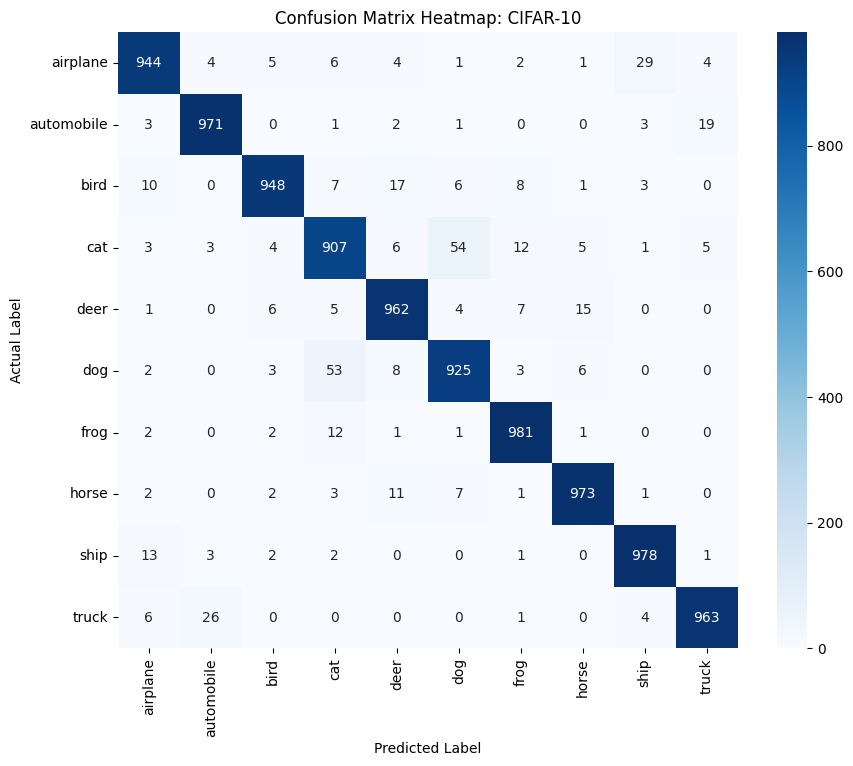

In [27]:
import seaborn as sns


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)


y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Confusion Matrix Heatmap: CIFAR-10')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()


# Confusion Matrix Observations (CIFAR-10)
## EfficientNetV2-Medium — Phase 2 Fine-Tuning Results

## Overall Performance
- The model demonstrates excellent classification performance across all 10 CIFAR-10 classes,
  achieving an overall test accuracy of **95.52%**.
- Predictions are heavily concentrated along the diagonal of the confusion matrix,
  confirming that selective fine-tuning of the last convolutional stages was effective.
- Eight out of ten classes achieved individual accuracy above **95%**, reflecting the strength
  of ImageNet pre-trained feature representations adapted to CIFAR-10.
- The two weakest classes — Cat and Dog — remain the primary source of misclassification,
  a known limitation tied to shared visual texture and body structure rather than model failure.

---

# Class-wise Observations

| Class | Correct Predictions | Accuracy | Observation |
|---|---|---|---|
| Airplane | 944 | 94.4% | Strong overall performance. Primary confusion is toward **Ship (29)** — both share open, featureless backgrounds (sky vs. water). |
| Automobile | 971 | 97.1% | Second highest accuracy. Minor confusion with **Truck (19)** due to shared vehicle structure. |
| Bird | 948 | 94.8% | Solid performance. Scattered confusion across **Deer (17)**, **Frog (8)**, and **Cat (7)** — all involving organic shapes and outdoor scenes. |
| Cat | 907 | 90.7% | Weakest-performing class. Heavily confused with **Dog (54)** — similar fur texture, ear shape, and body proportions make this the hardest boundary in CIFAR-10. |
| Deer | 962 | 96.2% | Strong classification. Most notable confusion is toward **Horse (15)** — both are large four-legged animals with similar silhouettes. |
| Dog | 925 | 92.5% | Second weakest class. Mirrors the Cat issue — **53 samples predicted as Cat**, confirming the Cat↔Dog boundary is the model's primary blind spot. |
| Frog | 981 | 98.1% | Best-performing class. Frogs have highly distinct color patterns and body shape. Only **Cat (12)** causes minor confusion. |
| Horse | 973 | 97.3% | Excellent accuracy. Small confusion toward **Deer (11)** and **Dog (7)** — both involve four-legged animals in natural settings. |
| Ship | 978 | 97.8% | Near-perfect classification. Only **Airplane (13)** causes meaningful confusion — the open background similarity works both ways. |
| Truck | 963 | 96.3% | High accuracy with the sole notable error being **Automobile (26)** — expected, as both are road vehicles sharing structural features. |

---

## Key Failure Patterns

| Misclassification | Count | Root Cause |
|---|---|---|
| Cat → Dog | 54 | Shared fur texture, ear shape, body proportions |
| Dog → Cat | 53 | Same bilateral confusion — symmetric visual overlap |
| Airplane → Ship | 29 | Open featureless backgrounds (sky vs. water) |
| Truck → Automobile | 26 | Shared vehicle body structure and road context |
| Deer → Horse | 15 | Similar four-legged silhouette in natural scenes |

In [31]:
# Change the underscore to a hyphen
EfficientNetV2M_base = model.get_layer('efficientnetv2-m')

# Print last 15 layers of the base model to find the target layer
for layer in EfficientNetV2M_base.layers[-30:]:
    print(layer.name)


block7d_dwconv2
block7d_bn
block7d_activation
block7d_se_squeeze
block7d_se_reshape
block7d_se_reduce
block7d_se_expand
block7d_se_excite
block7d_project_conv
block7d_project_bn
block7d_drop
block7d_add
block7e_expand_conv
block7e_expand_bn
block7e_expand_activation
block7e_dwconv2
block7e_bn
block7e_activation
block7e_se_squeeze
block7e_se_reshape
block7e_se_reduce
block7e_se_expand
block7e_se_excite
block7e_project_conv
block7e_project_bn
block7e_drop
block7e_add
top_conv
top_bn
top_activation


In [54]:
import inspect
import tensorflow as tf
import numpy as np

def get_efficientnet_gradcam_heatmap(img_array, model, last_conv_layer_name='top_conv'):

    # ── Step 1: Extract base model from inside the outer model ──
    efficientnet_base = model.get_layer('efficientnetv2-m')
    
    # ── Step 2: Build grad model scoped to EfficientNetV2M only ──
    efficientnet_grad_model = tf.keras.Model(
        inputs  = efficientnet_base.input,
        outputs = [
            efficientnet_base.get_layer(last_conv_layer_name).output,  
            efficientnet_base.output                                   
        ]
    )

    with tf.GradientTape() as tape:
        x = tf.cast(img_array, tf.float32)
        conv_outputs = None

        # ── Step 3: Walk through the OUTER model layer by layer ──
        for layer in model.layers:
            
            # CRITICAL FIX: Skip the InputLayer placeholder
            if isinstance(layer, tf.keras.layers.InputLayer):
                continue

            if layer.name == 'efficientnetv2-m':
                # Intercept here — run grad model instead of base model directly
                conv_outputs, x = efficientnet_grad_model(x, training=False)
                tape.watch(conv_outputs)

            else:
                sig = inspect.signature(layer.call)
                if 'training' in sig.parameters:
                    x = layer(x, training=False)
                else:
                    x = layer(x)

        predictions = x  

        # ── Step 4: Isolate gradient signal for the top predicted class ──
        top_pred_index = tf.argmax(predictions[0])
        class_channel  = predictions[:, top_pred_index]

    # ── Step 5: Gradient of class score w.r.t. target conv feature maps ──
    grads = tape.gradient(class_channel, conv_outputs)

    # ── Step 6: Global average pool → importance weight per channel ──
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # ── Step 7: Weight each feature map by its importance ──
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # ── Step 8: ReLU + safe normalize ──
    heatmap = tf.maximum(heatmap, 0)
    max_val = tf.math.reduce_max(heatmap)
    if max_val == 0:
        max_val = tf.constant(1e-10)
    heatmap = heatmap / max_val

    return heatmap.numpy()

E0000 00:00:1780220240.334341   16002 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


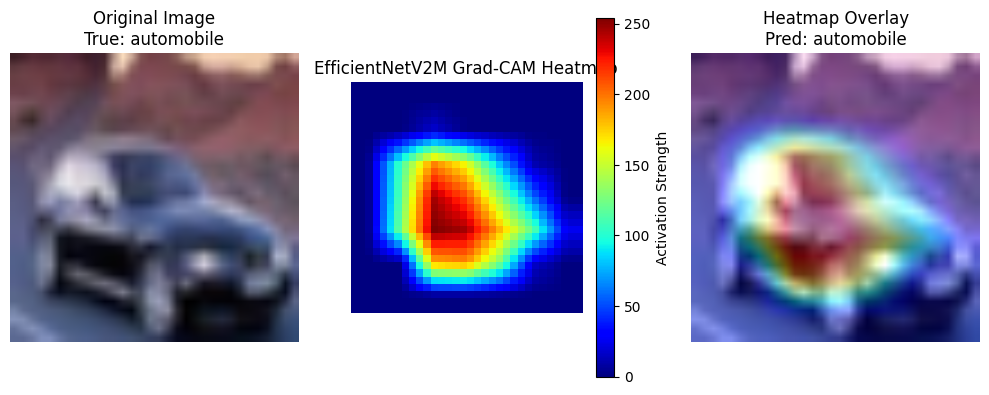

In [74]:
last_effnet_conv = 'top_conv'
idx = 390

# 1. ── Safe Image Extraction ──
# Pull the raw tensor exactly as it exists in your dataset
img_raw = X_test[idx]

# Safely format for visual display without exploding the magnitude
if np.max(img_raw) <= 1.0:
    img_display = (img_raw * 255.0).astype("uint8")
else:
    img_display = img_raw.astype("uint8")

# 2. ── The Pipeline Correction ──
# CRITICAL FIX: Do NOT use cv2.resize. Pass the 32x32 tensor.
# Your outer model's internal Resizing layer will handle the upscaling mathematically.
outer_input = np.expand_dims(img_raw, axis=0).astype('float32') # Shape: (1, 32, 32, 3)

# 3. ── Generate Heatmap ──
heatmap = get_efficientnet_gradcam_heatmap(outer_input, model, last_effnet_conv)

# 4. ── Resize Heatmap ──
heatmap_resized = cv2.resize(heatmap, (32, 32))
heatmap_uint8   = np.uint8(255 * heatmap_resized)

# 5. ── Colormap & Safe Blending ──
heatmap_color = cv2.applyColorMap(heatmap_uint8, cv2.COLORMAP_JET)
heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)

# CRITICAL FIX: Clip the addition to prevent float/uint8 visual overflow
superimposed_img = heatmap_color * 0.4 + img_display
superimposed_img = np.clip(superimposed_img, 0, 255).astype("uint8")

# ── Get Prediction ──
pred_class  = class_names[np.argmax(model.predict(outer_input, verbose=0))]
true_class  = class_names[y_test[idx][0]]

# ── Plot ──
plt.figure(figsize=(10, 4))

plt.subplot(1, 3, 1)
plt.imshow(img_display, interpolation='bilinear')
plt.title(f"Original Image\nTrue: {true_class}")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(heatmap_uint8, cmap='jet')
plt.title("EfficientNetV2M Grad-CAM Heatmap")
plt.colorbar(label="Activation Strength")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(superimposed_img, interpolation='bilinear')
plt.title(f"Heatmap Overlay\nPred: {pred_class}")
plt.axis("off")

plt.tight_layout()
plt.show()